In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
from PIL import Image
from tqdm import tqdm

# Verify GPU is detected
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Using device: cuda
✅ CUDA available: True
✅ GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU
✅ GPU Memory: 6.1 GB


In [2]:
# ============================================================
# CONFIGURATION — Change DATASET_PATH if your folder is different
# ============================================================
DATASET_PATH = "../dataset/dataset-resized"   # Path relative to the notebooks/ folder
BATCH_SIZE   = 32
IMAGE_SIZE   = 224    # ResNet expects 224x224
NUM_EPOCHS   = 20
LEARNING_RATE = 0.001
NUM_CLASSES  = 6      # glass, paper, cardboard, plastic, metal, trash

# Class names (must match your folder names exactly)
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print(f"Dataset path: {os.path.abspath(DATASET_PATH)}")
print(f"Classes: {CLASS_NAMES}")

Dataset path: /home/abhyansh/college-shit/SEPM_project/ecosort-backend/dataset/dataset-resized
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
# Training transforms: augmentation applied to make model more robust
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    # ImageNet normalization values — required because we use a pretrained ResNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms: NO augmentation, just resize and normalize
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load the full dataset using ImageFolder
# ImageFolder automatically reads subfolder names as class labels
full_dataset = datasets.ImageFolder(root=DATASET_PATH)

print(f"✅ Total images found: {len(full_dataset)}")
print(f"✅ Classes detected: {full_dataset.classes}")

# Split: 70% training, 15% validation, 15% test
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Fixed seed for reproducibility
)

# Apply separate transforms to each split
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform   = val_transforms
test_dataset.dataset.transform  = val_transforms

# Create DataLoaders (these feed batches of images to the GPU)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\n📦 Training samples:   {len(train_dataset)}")
print(f"📦 Validation samples: {len(val_dataset)}")
print(f"📦 Test samples:       {len(test_dataset)}")

✅ Total images found: 2527
✅ Classes detected: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

📦 Training samples:   1768
📦 Validation samples: 379
📦 Test samples:       380


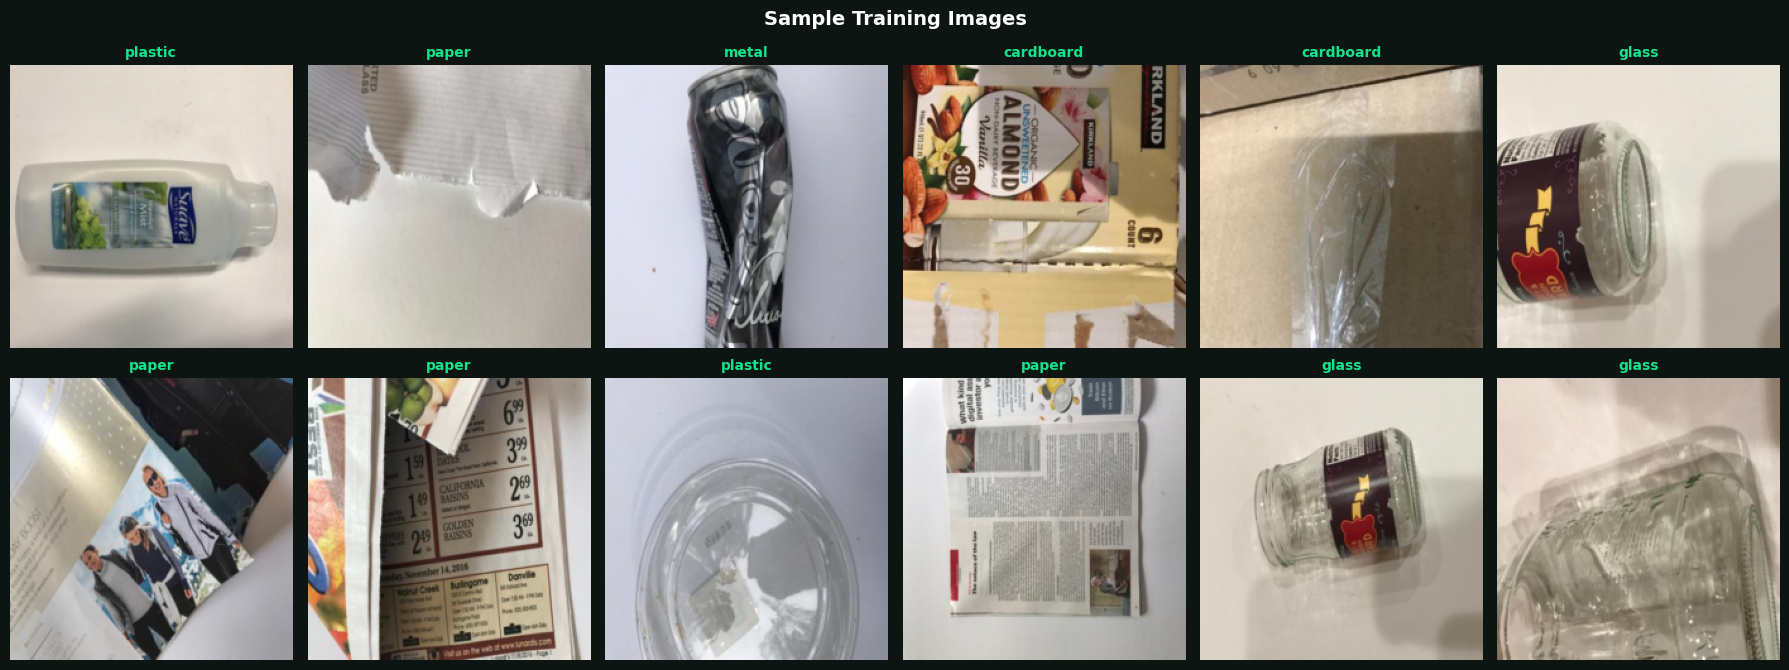

In [4]:
def imshow_batch(loader, class_names):
    images, labels = next(iter(loader))
    
    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images = images * std + mean
    images = images.clamp(0, 1)
    
    fig, axes = plt.subplots(2, 6, figsize=(18, 7))
    fig.patch.set_facecolor('#0d1512')
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            img = images[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(class_names[labels[i]], color='#10e58c', fontsize=10, fontweight='bold')
        ax.axis('off')
        ax.set_facecolor('#0d1512')
    
    plt.suptitle('Sample Training Images', color='white', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

imshow_batch(train_loader, CLASS_NAMES)

In [5]:
def build_model(num_classes, freeze_backbone=True):
    """
    Loads pretrained ResNet18 and replaces the final fully-connected layer.
    
    freeze_backbone=True: Only train the final layer (fast, good for small datasets)
    freeze_backbone=False: Train all layers (slower, better accuracy if you have lots of data)
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    if freeze_backbone:
        # Freeze all layers except the final one
        for param in model.parameters():
            param.requires_grad = False
    
    # Get the number of features going into the final layer
    in_features = model.fc.in_features  # This is 512 for ResNet18
    
    # Replace the final layer with our custom classifier
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),          # Dropout prevents overfitting
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)  # 6 output nodes, one per waste category
    )
    
    return model

model = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)
model = model.to(device)  # Move model to GPU

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model built successfully")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nModel's final classifier layer:")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/abhyansh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:03<00:00, 13.2MB/s]

✅ Model built successfully
   Total parameters:     11,309,382
   Trainable parameters: 132,870
   Frozen parameters:    11,176,512

Model's final classifier layer:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=6, bias=True)
)


In [6]:
# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer — only optimize the trainable (unfrozen) parameters
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4   # L2 regularization to prevent overfitting
)

# Learning rate scheduler: reduces LR if validation loss stops improving
# This is like telling the model "take smaller steps as you get closer to the answer"
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

print("✅ Loss function: CrossEntropyLoss")
print("✅ Optimizer: Adam")
print("✅ Scheduler: ReduceLROnPlateau (halves LR if val_loss doesn't improve for 3 epochs)")

✅ Loss function: CrossEntropyLoss
✅ Optimizer: Adam
✅ Scheduler: ReduceLROnPlateau (halves LR if val_loss doesn't improve for 3 epochs)


/home/abhyansh/college-shit/SEPM_project/ecosort-backend/ecosort-env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()           # Clear previous gradients
        outputs = model(images)          # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Update weights
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():   # No gradient calculation needed during validation
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return running_loss / total, correct / total


# ============================================================
# MAIN TRAINING LOOP
# ============================================================
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
SAVE_PATH = "../saved_models/ecosort_model.pth"
os.makedirs("../saved_models", exist_ok=True)

print("🚀 Starting Training...\n")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Val Loss':<14} {'Val Acc':<12}")
print("─" * 62)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'class_names': CLASS_NAMES
        }, SAVE_PATH)
        saved_marker = " ✅ SAVED"
    else:
        saved_marker = ""
    
    print(f"{epoch:<8} {train_loss:<14.4f} {train_acc*100:<14.2f} {val_loss:<14.4f} {val_acc*100:<12.2f}{saved_marker}")

print(f"\n🏆 Training complete. Best val loss: {best_val_loss:.4f}")
print(f"💾 Best model saved to: {SAVE_PATH}")

🚀 Starting Training...

Epoch    Train Loss     Train Acc      Val Loss       Val Acc     
──────────────────────────────────────────────────────────────


1        1.1683         56.67          0.7609         72.30        ✅ SAVED


2        0.7606         72.12          0.6684         71.77        ✅ SAVED


3        0.7021         73.98          0.6505         75.99        ✅ SAVED


4        0.6293         77.77          0.5935         77.04        ✅ SAVED


...

16       0.4485         82.92          0.5161         80.74       


17       0.4270         83.94          0.5043         81.27        ✅ SAVED


18       0.3935         86.60          0.5047         80.74       


19       0.3964         86.31          0.5194         80.47       


20       0.4055         85.52          0.5233         78.63       

🏆 Training complete. Best val loss: 0.5043
💾 Best model saved to: ../saved_models/ecosort_model.pth


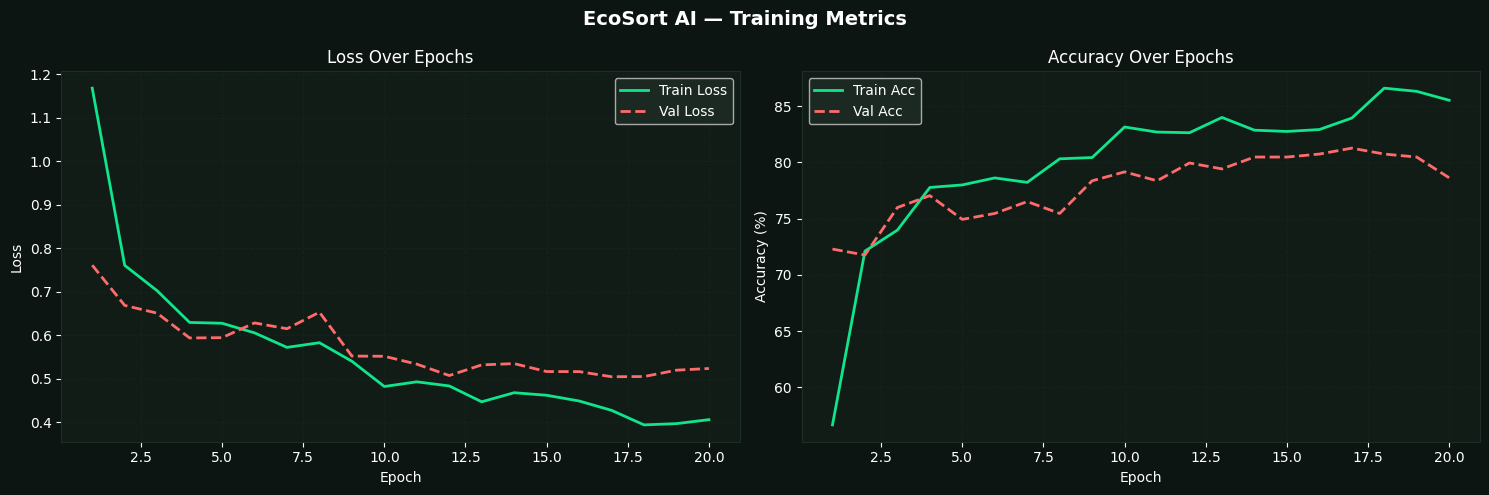

📊 Chart saved to saved_models/training_curves.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0d1512')

for ax in (ax1, ax2):
    ax.set_facecolor('#121c17')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2d26')

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], color='#10e58c', linewidth=2, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   color='#ff6b6b', linewidth=2, label='Val Loss',   linestyle='--')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(facecolor='#1e2d26', labelcolor='white')
ax1.grid(True, linestyle='--', alpha=0.3, color='#1e2d26')

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], color='#10e58c', linewidth=2, label='Train Acc')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   color='#ff6b6b', linewidth=2, label='Val Acc',   linestyle='--')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(facecolor='#1e2d26', labelcolor='white')
ax2.grid(True, linestyle='--', alpha=0.3, color='#1e2d26')

plt.suptitle('EcoSort AI — Training Metrics', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../saved_models/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved to saved_models/training_curves.png")

/tmp/ipykernel_158670/1771192330.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_PATH, map_location=device)


✅ Loaded best model from epoch 17 (val_acc: 81.27%)



Testing: 100%|██████████| 12/12 [00:00<00:00, 13.95it/s]


📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.93      0.92      0.92        59
       glass       0.82      0.78      0.80        78
       metal       0.75      0.77      0.76        61
       paper       0.79      0.92      0.85        92
     plastic       0.81      0.76      0.78        66
       trash       0.73      0.46      0.56        24

    accuracy                           0.81       380
   macro avg       0.80      0.77      0.78       380
weighted avg       0.81      0.81      0.81       380



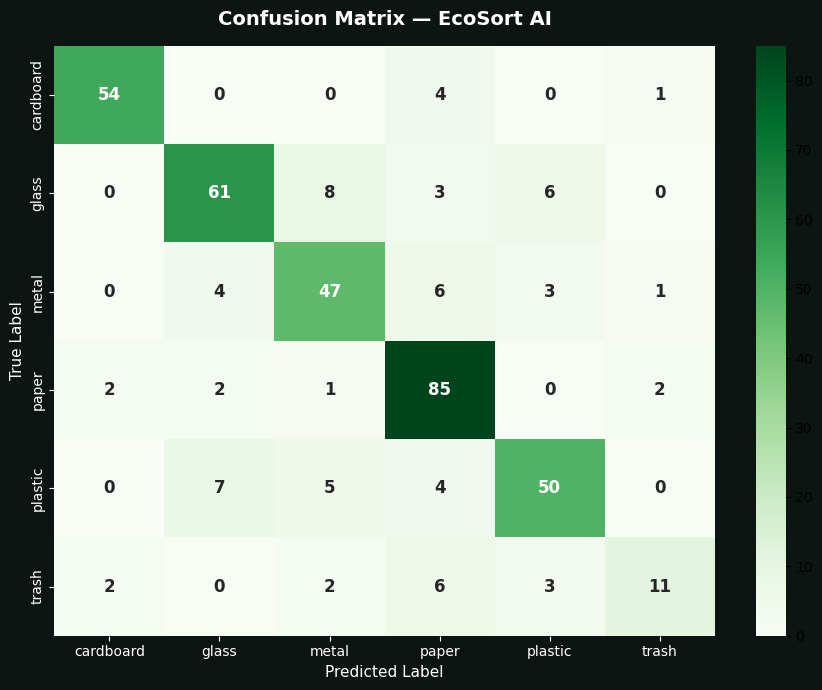

In [9]:
# Load the best saved model for evaluation
checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']} (val_acc: {checkpoint['val_acc']*100:.2f}%)\n")

# Run on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Print classification report
print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1512')
ax.set_facecolor('#121c17')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, cbar=True,
            annot_kws={"size": 12, "weight": "bold"})

ax.set_title('Confusion Matrix — EcoSort AI', color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', color='white', fontsize=11)
ax.set_ylabel('True Label',      color='white', fontsize=11)
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('../saved_models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

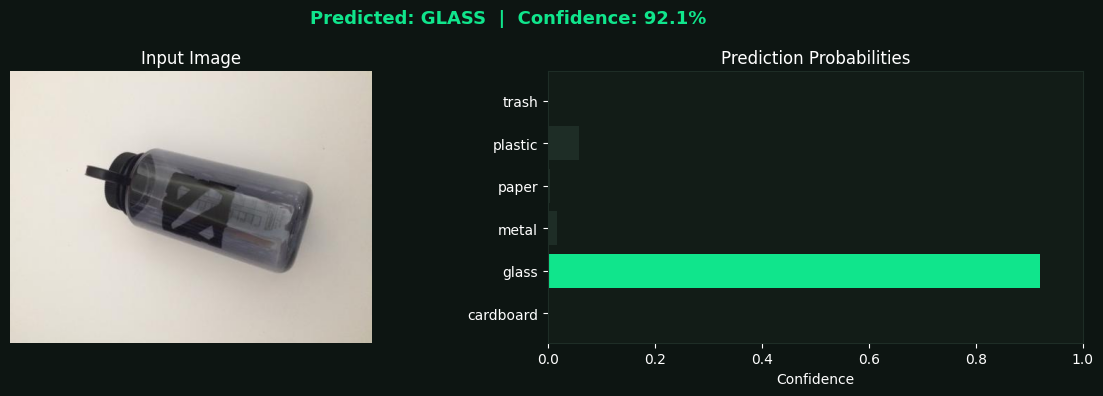


🤖 Model says: GLASS (92.1% confident)


In [10]:
def predict_single_image(image_path, model, class_names, device):
    """
    Takes any image path, runs it through the model, and returns the predicted class.
    This is exactly what main.py will call when connected to the backend.
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension
    
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        confidence, predicted_idx = probabilities.max(0)
    
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()
    
    # Display result
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#0d1512')
    
    ax1.imshow(img)
    ax1.set_title(f'Input Image', color='white')
    ax1.axis('off')
    ax1.set_facecolor('#0d1512')
    
    colors = ['#10e58c' if i == predicted_idx.item() else '#1e2d26' for i in range(len(class_names))]
    bars = ax2.barh(class_names, probabilities.cpu().numpy(), color=colors)
    ax2.set_facecolor('#121c17')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Confidence', color='white')
    ax2.set_title('Prediction Probabilities', color='white')
    ax2.tick_params(colors='white')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#1e2d26')
    
    plt.suptitle(f'Predicted: {predicted_class.upper()}  |  Confidence: {confidence_score*100:.1f}%',
                 color='#10e58c', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence_score

# Test it — replace this path with any image from your dataset
test_image_path = f"{DATASET_PATH}/plastic/plastic1.jpg"
predicted_class, confidence = predict_single_image(test_image_path, model, CLASS_NAMES, device)
print(f"\n🤖 Model says: {predicted_class.upper()} ({confidence*100:.1f}% confident)")